# Projet 7 - Implémentez un modèle de scoring
Utilisation d'un Kernel pour gagner du temps sur le préprocessing et le feature engineering du dataset.
## Imports

In [6]:
import numpy as np
import pandas as pd
import gc
import time
from contextlib import contextmanager

from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix, classification_report, make_scorer, precision_recall_curve
from sklearn.model_selection import learning_curve, GridSearchCV, RandomizedSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import mlflow
from mlflow.tracking import MlflowClient

from sklearn import set_config
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [7]:
pd.set_option('display.max_row', 800)
pd.set_option("display.max_columns", None)
set_config(display="text")
sns.set_theme(style='whitegrid', palette='pastel')

## Accès aux données

In [69]:
chemin = "G:/Mon Drive/Yann Pham-Van - Data Scientist - OpenClassrooms/Projet7-Implémentez un modèle de scoring/data/"

## Fonctions

In [9]:
@contextmanager
def timer(title):
    t0 = time.time()
    yield
    print("{} - fait en {:.0f}s".format(title, time.time() - t0))

# One-hot encoding for categorical columns with get_dummies
def one_hot_encoder(df, nan_as_category = True):
    original_columns = list(df.columns)
    categorical_columns = [col for col in df.columns if df[col].dtype == 'object']
    df = pd.get_dummies(df, columns= categorical_columns, dummy_na= nan_as_category, dtype=int)
    new_columns = [c for c in df.columns if c not in original_columns]
    return df, new_columns

# Preprocess application_train.csv and application_test.csv
def application_train_test(num_rows = None, nan_as_category = False):
    # Read data and merge
    df = pd.read_csv(chemin+"input/"+'application_train.csv', nrows= num_rows)
    test_df = pd.read_csv(chemin+"input/"+'application_test.csv', nrows= num_rows)
    print("Train samples: {}, test samples: {}".format(len(df), len(test_df)))
    # df = df.append(test_df).reset_index()
    df = pd.concat([df, test_df], ignore_index=True)
    # Optional: Remove 4 applications with XNA CODE_GENDER (train set)
    df = df[df['CODE_GENDER'] != 'XNA']
    
    # Categorical features with Binary encode (0 or 1; two categories)
    for bin_feature in ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
        df[bin_feature], uniques = pd.factorize(df[bin_feature])
    # Categorical features with One-Hot encode
    df, cat_cols = one_hot_encoder(df, nan_as_category)
    
    # NaN values for DAYS_EMPLOYED: 365.243 -> nan
    df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace= True)
    # Some simple new features (percentages)
    df['DAYS_EMPLOYED_PERC'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']
    df['INCOME_CREDIT_PERC'] = df['AMT_INCOME_TOTAL'] / df['AMT_CREDIT']
    df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']
    df['ANNUITY_INCOME_PERC'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
    df['PAYMENT_RATE'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']
    del test_df
    gc.collect()
    return df

# Preprocess bureau.csv and bureau_balance.csv
def bureau_and_balance(num_rows = None, nan_as_category = True):
    bureau = pd.read_csv(chemin+"input/"+'bureau.csv', nrows = num_rows)
    bb = pd.read_csv(chemin+"input/"+'bureau_balance.csv', nrows = num_rows)
    bb, bb_cat = one_hot_encoder(bb, nan_as_category)
    bureau, bureau_cat = one_hot_encoder(bureau, nan_as_category)
    
    # Bureau balance: Perform aggregations and merge with bureau.csv
    bb_aggregations = {'MONTHS_BALANCE': ['min', 'max', 'size']}
    for col in bb_cat:
        bb_aggregations[col] = ['mean']
    bb_agg = bb.groupby('SK_ID_BUREAU').agg(bb_aggregations)
    bb_agg.columns = pd.Index([e[0] + "_" + e[1].upper() for e in bb_agg.columns.tolist()])
    bureau = bureau.join(bb_agg, how='left', on='SK_ID_BUREAU')
    bureau.drop(['SK_ID_BUREAU'], axis=1, inplace= True)
    del bb, bb_agg
    gc.collect()
    
    # Bureau and bureau_balance numeric features
    num_aggregations = {
        'DAYS_CREDIT': ['min', 'max', 'mean', 'var'],
        'DAYS_CREDIT_ENDDATE': ['min', 'max', 'mean'],
        'DAYS_CREDIT_UPDATE': ['mean'],
        'CREDIT_DAY_OVERDUE': ['max', 'mean'],
        'AMT_CREDIT_MAX_OVERDUE': ['mean'],
        'AMT_CREDIT_SUM': ['max', 'mean', 'sum'],
        'AMT_CREDIT_SUM_DEBT': ['max', 'mean', 'sum'],
        'AMT_CREDIT_SUM_OVERDUE': ['mean'],
        'AMT_CREDIT_SUM_LIMIT': ['mean', 'sum'],
        'AMT_ANNUITY': ['max', 'mean'],
        'CNT_CREDIT_PROLONG': ['sum'],
        'MONTHS_BALANCE_MIN': ['min'],
        'MONTHS_BALANCE_MAX': ['max'],
        'MONTHS_BALANCE_SIZE': ['mean', 'sum']
    }
    # Bureau and bureau_balance categorical features
    cat_aggregations = {}
    for cat in bureau_cat: cat_aggregations[cat] = ['mean']
    for cat in bb_cat: cat_aggregations[cat + "_MEAN"] = ['mean']
    
    bureau_agg = bureau.groupby('SK_ID_CURR').agg({**num_aggregations, **cat_aggregations})
    bureau_agg.columns = pd.Index(['BURO_' + e[0] + "_" + e[1].upper() for e in bureau_agg.columns.tolist()])
    # Bureau: Active credits - using only numerical aggregations
    active = bureau[bureau['CREDIT_ACTIVE_Active'] == 1]
    active_agg = active.groupby('SK_ID_CURR').agg(num_aggregations)
    active_agg.columns = pd.Index(['ACTIVE_' + e[0] + "_" + e[1].upper() for e in active_agg.columns.tolist()])
    bureau_agg = bureau_agg.join(active_agg, how='left', on='SK_ID_CURR')
    del active, active_agg
    gc.collect()
    # Bureau: Closed credits - using only numerical aggregations
    closed = bureau[bureau['CREDIT_ACTIVE_Closed'] == 1]
    closed_agg = closed.groupby('SK_ID_CURR').agg(num_aggregations)
    closed_agg.columns = pd.Index(['CLOSED_' + e[0] + "_" + e[1].upper() for e in closed_agg.columns.tolist()])
    bureau_agg = bureau_agg.join(closed_agg, how='left', on='SK_ID_CURR')
    del closed, closed_agg, bureau
    gc.collect()
    return bureau_agg

# Preprocess previous_applications.csv
def previous_applications(num_rows = None, nan_as_category = True):
    prev = pd.read_csv(chemin+"input/"+'previous_application.csv', nrows = num_rows)
    prev, cat_cols = one_hot_encoder(prev, nan_as_category= True)
    # Days 365.243 values -> nan
    prev['DAYS_FIRST_DRAWING'].replace(365243, np.nan, inplace= True)
    prev['DAYS_FIRST_DUE'].replace(365243, np.nan, inplace= True)
    prev['DAYS_LAST_DUE_1ST_VERSION'].replace(365243, np.nan, inplace= True)
    prev['DAYS_LAST_DUE'].replace(365243, np.nan, inplace= True)
    prev['DAYS_TERMINATION'].replace(365243, np.nan, inplace= True)
    # Add feature: value ask / value received percentage
    prev['APP_CREDIT_PERC'] = prev['AMT_APPLICATION'] / prev['AMT_CREDIT']
    # Previous applications numeric features
    num_aggregations = {
        'AMT_ANNUITY': ['min', 'max', 'mean'],
        'AMT_APPLICATION': ['min', 'max', 'mean'],
        'AMT_CREDIT': ['min', 'max', 'mean'],
        'APP_CREDIT_PERC': ['min', 'max', 'mean', 'var'],
        'AMT_DOWN_PAYMENT': ['min', 'max', 'mean'],
        'AMT_GOODS_PRICE': ['min', 'max', 'mean'],
        'HOUR_APPR_PROCESS_START': ['min', 'max', 'mean'],
        'RATE_DOWN_PAYMENT': ['min', 'max', 'mean'],
        'DAYS_DECISION': ['min', 'max', 'mean'],
        'CNT_PAYMENT': ['mean', 'sum'],
    }
    # Previous applications categorical features
    cat_aggregations = {}
    for cat in cat_cols:
        cat_aggregations[cat] = ['mean']
    
    prev_agg = prev.groupby('SK_ID_CURR').agg({**num_aggregations, **cat_aggregations})
    prev_agg.columns = pd.Index(['PREV_' + e[0] + "_" + e[1].upper() for e in prev_agg.columns.tolist()])
    # Previous Applications: Approved Applications - only numerical features
    approved = prev[prev['NAME_CONTRACT_STATUS_Approved'] == 1]
    approved_agg = approved.groupby('SK_ID_CURR').agg(num_aggregations)
    approved_agg.columns = pd.Index(['APPROVED_' + e[0] + "_" + e[1].upper() for e in approved_agg.columns.tolist()])
    prev_agg = prev_agg.join(approved_agg, how='left', on='SK_ID_CURR')
    # Previous Applications: Refused Applications - only numerical features
    refused = prev[prev['NAME_CONTRACT_STATUS_Refused'] == 1]
    refused_agg = refused.groupby('SK_ID_CURR').agg(num_aggregations)
    refused_agg.columns = pd.Index(['REFUSED_' + e[0] + "_" + e[1].upper() for e in refused_agg.columns.tolist()])
    prev_agg = prev_agg.join(refused_agg, how='left', on='SK_ID_CURR')
    del refused, refused_agg, approved, approved_agg, prev
    gc.collect()
    return prev_agg

# Preprocess POS_CASH_balance.csv
def pos_cash(num_rows = None, nan_as_category = True):
    pos = pd.read_csv(chemin+"input/"+'POS_CASH_balance.csv', nrows = num_rows)
    pos, cat_cols = one_hot_encoder(pos, nan_as_category= True)
    # Features
    aggregations = {
        'MONTHS_BALANCE': ['max', 'mean', 'size'],
        'SK_DPD': ['max', 'mean'],
        'SK_DPD_DEF': ['max', 'mean']
    }
    for cat in cat_cols:
        aggregations[cat] = ['mean']
    
    pos_agg = pos.groupby('SK_ID_CURR').agg(aggregations)
    pos_agg.columns = pd.Index(['POS_' + e[0] + "_" + e[1].upper() for e in pos_agg.columns.tolist()])
    # Count pos cash accounts
    pos_agg['POS_COUNT'] = pos.groupby('SK_ID_CURR').size()
    del pos
    gc.collect()
    return pos_agg
    
# Preprocess installments_payments.csv
def installments_payments(num_rows = None, nan_as_category = True):
    ins = pd.read_csv(chemin+"input/"+'installments_payments.csv', nrows = num_rows)
    ins, cat_cols = one_hot_encoder(ins, nan_as_category= True)
    # Percentage and difference paid in each installment (amount paid and installment value)
    ins['PAYMENT_PERC'] = ins['AMT_PAYMENT'] / ins['AMT_INSTALMENT']
    ins['PAYMENT_DIFF'] = ins['AMT_INSTALMENT'] - ins['AMT_PAYMENT']
    # Days past due and days before due (no negative values)
    ins['DPD'] = ins['DAYS_ENTRY_PAYMENT'] - ins['DAYS_INSTALMENT']
    ins['DBD'] = ins['DAYS_INSTALMENT'] - ins['DAYS_ENTRY_PAYMENT']
    ins['DPD'] = ins['DPD'].apply(lambda x: x if x > 0 else 0)
    ins['DBD'] = ins['DBD'].apply(lambda x: x if x > 0 else 0)
    # Features: Perform aggregations
    aggregations = {
        'NUM_INSTALMENT_VERSION': ['nunique'],
        'DPD': ['max', 'mean', 'sum'],
        'DBD': ['max', 'mean', 'sum'],
        'PAYMENT_PERC': ['max', 'mean', 'sum', 'var'],
        'PAYMENT_DIFF': ['max', 'mean', 'sum', 'var'],
        'AMT_INSTALMENT': ['max', 'mean', 'sum'],
        'AMT_PAYMENT': ['min', 'max', 'mean', 'sum'],
        'DAYS_ENTRY_PAYMENT': ['max', 'mean', 'sum']
    }
    for cat in cat_cols:
        aggregations[cat] = ['mean']
    ins_agg = ins.groupby('SK_ID_CURR').agg(aggregations)
    ins_agg.columns = pd.Index(['INSTAL_' + e[0] + "_" + e[1].upper() for e in ins_agg.columns.tolist()])
    # Count installments accounts
    ins_agg['INSTAL_COUNT'] = ins.groupby('SK_ID_CURR').size()
    del ins
    gc.collect()
    return ins_agg

# Preprocess credit_card_balance.csv
def credit_card_balance(num_rows = None, nan_as_category = True):
    cc = pd.read_csv(chemin+"input/"+'credit_card_balance.csv', nrows = num_rows)
    cc, cat_cols = one_hot_encoder(cc, nan_as_category= True)
    # General aggregations
    cc.drop(['SK_ID_PREV'], axis= 1, inplace = True)
    cc_agg = cc.groupby('SK_ID_CURR').agg(['min', 'max', 'mean', 'sum', 'var'])
    cc_agg.columns = pd.Index(['CC_' + e[0] + "_" + e[1].upper() for e in cc_agg.columns.tolist()])
    # Count credit card lines
    cc_agg['CC_COUNT'] = cc.groupby('SK_ID_CURR').size()
    del cc
    gc.collect()
    return cc_agg

# Fonction principale appelant les fonctions précédentes
def main(debug = False):
    num_rows = 10000 if debug else None
    df = application_train_test(num_rows)
    with timer("Process bureau and bureau_balance"):
        bureau = bureau_and_balance(num_rows)
        print("Bureau df shape:", bureau.shape)
        df = df.join(bureau, how='left', on='SK_ID_CURR')
        del bureau
        gc.collect()
    with timer("Process previous_applications"):
        prev = previous_applications(num_rows)
        print("Previous applications df shape:", prev.shape)
        df = df.join(prev, how='left', on='SK_ID_CURR')
        del prev
        gc.collect()
    with timer("Process POS-CASH balance"):
        pos = pos_cash(num_rows)
        print("Pos-cash balance df shape:", pos.shape)
        df = df.join(pos, how='left', on='SK_ID_CURR')
        del pos
        gc.collect()
    with timer("Process installments payments"):
        ins = installments_payments(num_rows)
        print("Installments payments df shape:", ins.shape)
        df = df.join(ins, how='left', on='SK_ID_CURR')
        del ins
        gc.collect()
    with timer("Process credit card balance"):
        cc = credit_card_balance(num_rows)
        print("Credit card balance df shape:", cc.shape)
        df = df.join(cc, how='left', on='SK_ID_CURR')
        del cc
        gc.collect()

    return df

## Lancement du kernel

In [10]:
with timer("______________________________________________________________________\nFull préprocessing & Feature engineering"):
    data = main()

Train samples: 307511, test samples: 48744
Bureau df shape: (305811, 116)
Process bureau and bureau_balance - fait en 13s
Previous applications df shape: (338857, 249)
Process previous_applications - fait en 13s
Pos-cash balance df shape: (337252, 18)
Process POS-CASH balance - fait en 7s
Installments payments df shape: (339587, 26)
Process installments payments - fait en 19s
Credit card balance df shape: (103558, 141)
Process credit card balance - fait en 9s
______________________________________________________________________
Full préprocessing & Feature engineering - fait en 63s


## Observations préliminaires

In [11]:
df = data.copy()

In [12]:
df.shape

(356251, 797)

In [13]:
df.head(5)

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,NAME_TYPE_SUITE_Children,NAME_TYPE_SUITE_Family,NAME_TYPE_SUITE_Group of people,NAME_TYPE_SUITE_Other_A,NAME_TYPE_SUITE_Other_B,"NAME_TYPE_SUITE_Spouse, partner",NAME_TYPE_SUITE_Unaccompanied,NAME_INCOME_TYPE_Businessman,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Maternity leave,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Unemployed,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Academic degree,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Civil marriage,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Unknown,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_Co-op apartment,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,OCCUPATION_TYPE_Accountants,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff,WEEKDAY_APPR_PROCESS_START_FRIDAY,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,ORGANIZATION_TYPE_Advertising,ORGANIZATION_TYPE_Agriculture,ORGANIZATION_TYPE_Bank,ORGANIZATION_TYPE_Business Entity Type 1,ORGANIZATION_TYPE_Business Entity Type 2,ORGANIZATION_

In [14]:
df.tail(5)

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,NAME_TYPE_SUITE_Children,NAME_TYPE_SUITE_Family,NAME_TYPE_SUITE_Group of people,NAME_TYPE_SUITE_Other_A,NAME_TYPE_SUITE_Other_B,"NAME_TYPE_SUITE_Spouse, partner",NAME_TYPE_SUITE_Unaccompanied,NAME_INCOME_TYPE_Businessman,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Maternity leave,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Unemployed,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Academic degree,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Civil marriage,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Unknown,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_Co-op apartment,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,OCCUPATION_TYPE_Accountants,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff,WEEKDAY_APPR_PROCESS_START_FRIDAY,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,ORGANIZATION_TYPE_Advertising,ORGANIZATION_TYPE_Agriculture,ORGANIZATION_TYPE_Bank,ORGANIZATION_TYPE_Business Entity Type 1,ORGANIZATION_TYPE_Business Entity Type 2,ORGANIZATION_

In [15]:
df.sample(5)

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,NAME_TYPE_SUITE_Children,NAME_TYPE_SUITE_Family,NAME_TYPE_SUITE_Group of people,NAME_TYPE_SUITE_Other_A,NAME_TYPE_SUITE_Other_B,"NAME_TYPE_SUITE_Spouse, partner",NAME_TYPE_SUITE_Unaccompanied,NAME_INCOME_TYPE_Businessman,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Maternity leave,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Unemployed,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Academic degree,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Civil marriage,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Unknown,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_Co-op apartment,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,OCCUPATION_TYPE_Accountants,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff,WEEKDAY_APPR_PROCESS_START_FRIDAY,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,ORGANIZATION_TYPE_Advertising,ORGANIZATION_TYPE_Agriculture,ORGANIZATION_TYPE_Bank,ORGANIZATION_TYPE_Business Entity Type 1,ORGANIZATION_TYPE_Business Entity Type 2,ORGANIZATION_

In [16]:
df.dtypes.value_counts()

float64    622
int32      133
int64       42
Name: count, dtype: int64

In [17]:
# Taux de manquants par colonnes
df.isna().mean().sort_values(ascending=False)

REFUSED_AMT_DOWN_PAYMENT_MIN                                             0.852343
REFUSED_RATE_DOWN_PAYMENT_MIN                                            0.852343
REFUSED_RATE_DOWN_PAYMENT_MEAN                                           0.852343
REFUSED_AMT_DOWN_PAYMENT_MEAN                                            0.852343
REFUSED_RATE_DOWN_PAYMENT_MAX                                            0.852343
REFUSED_AMT_DOWN_PAYMENT_MAX                                             0.852343
REFUSED_APP_CREDIT_PERC_VAR                                              0.836584
CC_AMT_PAYMENT_CURRENT_VAR                                               0.799012
CC_AMT_DRAWINGS_ATM_CURRENT_VAR                                          0.798760
CC_CNT_DRAWINGS_POS_CURRENT_VAR                                          0.798760
CC_AMT_DRAWINGS_POS_CURRENT_VAR                                          0.798760
CC_CNT_DRAWINGS_ATM_CURRENT_VAR                                          0.798760
CC_AMT_DRAWINGS_

In [18]:
# Valeurs dupliquées
df.duplicated().sum()

0

In [19]:
# Valeurs dupliquées sur colonnes hors Target
df.drop(columns='TARGET').duplicated().sum()

0

In [20]:
df.describe()

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,NAME_TYPE_SUITE_Children,NAME_TYPE_SUITE_Family,NAME_TYPE_SUITE_Group of people,NAME_TYPE_SUITE_Other_A,NAME_TYPE_SUITE_Other_B,"NAME_TYPE_SUITE_Spouse, partner",NAME_TYPE_SUITE_Unaccompanied,NAME_INCOME_TYPE_Businessman,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Maternity leave,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Unemployed,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Academic degree,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Civil marriage,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Unknown,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_Co-op apartment,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,OCCUPATION_TYPE_Accountants,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff,WEEKDAY_APPR_PROCESS_START_FRIDAY,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,ORGANIZATION_TYPE_Advertising,ORGANIZATION_TYPE_Agriculture,ORGANIZATION_TYPE_Bank,ORGANIZATION_TYPE_Business Entity Type 1,ORGANIZATION_TYPE_Business Entity Type 2,ORGANIZATION_

<Axes: ylabel='proportion'>

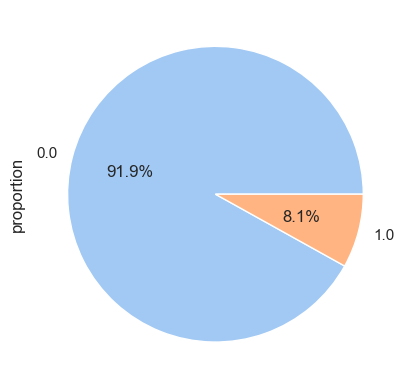

In [21]:
df['TARGET'].value_counts(normalize=True).plot(kind='pie', autopct='%.1f%%')

In [22]:
# Colonnes potentiellement inutiles, faute de variation des valeurs
df.nunique().sort_values()

PREV_NAME_CASH_LOAN_PURPOSE_nan_MEAN                                          1
PREV_NAME_CONTRACT_STATUS_nan_MEAN                                            1
PREV_CODE_REJECT_REASON_nan_MEAN                                              1
CC_NAME_CONTRACT_STATUS_Approved_MIN                                          1
POS_NAME_CONTRACT_STATUS_nan_MEAN                                             1
BURO_CREDIT_ACTIVE_nan_MEAN                                                   1
BURO_CREDIT_CURRENCY_nan_MEAN                                                 1
CC_NAME_CONTRACT_STATUS_Refused_MIN                                           1
BURO_CREDIT_TYPE_nan_MEAN                                                     1
BURO_STATUS_nan_MEAN_MEAN                                                     1
PREV_WEEKDAY_APPR_PROCESS_START_nan_MEAN                                      1
CC_NAME_CONTRACT_STATUS_nan_VAR                                               1
PREV_NAME_CONTRACT_TYPE_nan_MEAN        

## Préparation des données

### Fonctions de préparation

In [23]:
def reduction_taille_entier(df):
    """Transforme les entiers type 'int64' en type 'int32'."""
    df[df.columns[df.dtypes == 'int64']] = df[df.columns[df.dtypes == 'int64']].astype(dtype=np.int32, copy=False)
    return df

In [24]:
def suppression_colonnes_nan(df, taux_nan=0.8):
    """Suppression des variables avec trop de manquants"""
    df = df[df.columns[df.isna().mean() < taux_nan]]
        
    return df

In [25]:
def suppression_modalite_unique(df):
    """Suppression des variables avec une seule modalité"""
    df = df[df.columns[df.nunique() > 1]]
    return df

In [26]:
def separation_dataframe(df):
    """Séparation du dataframe en train et test correspondant aux dataframes du départ :
       application_train et application_test.
       Sauvegarde du dataframe_test pour usage ultérieur.
       Renvoi du dataframe_train pour la suite de la modélisation."""
    dataframe_train = df[df['TARGET'].notnull()]
    dataframe_test = df[df['TARGET'].isnull()]
    print("Dataframe avec target shape: {}, dataframe sans target shape: {}".format(dataframe_train.shape, dataframe_test.shape))
    dataframe_test.to_csv(chemin+"cleaned/"+"dataframe_test.csv", sep=',', index=False)
    del dataframe_test, df
    gc.collect()
    return dataframe_train

In [27]:
def dataframe_split(df):
    """Séparation du dataframe en 2 dataframes :
    - trainset
    - testset
    puis re-split de la target dans chacun des sets"""
    df = df.drop(columns={'SK_ID_CURR'})
    trainset , testset = train_test_split(df, test_size=0.3, random_state=39)
    X_train = trainset.drop(columns={'TARGET'})
    y_train = trainset['TARGET']
    X_test = testset.drop(columns={'TARGET'})
    y_test = testset['TARGET']
    print("Répartition de la target sur le jeu d'entraînement :")
    print(y_train.value_counts())
    print("Répartition de la target sur le jeu de test :")
    print(y_test.value_counts())
    del df, trainset, testset
    gc.collect()
    return X_train, y_train, X_test, y_test

In [28]:
def clean_infini(df):
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df

In [29]:
def preparation(df, taux_nan=0.8):
    """Fonction finalisant le pré-processing et renvoyant les 4 jeux d'entraînement et test"""
    with timer("Remplacement des valeurs 'int64' par des 'int32'"):
        df = reduction_taille_entier(df)
    with timer("Remplacement des valeurs 'infini' par des 'NaN'"):
        df = clean_infini(df)
    with timer("Suppression des variables avec trop de manquants"):
        df = suppression_colonnes_nan(df, taux_nan=0.8)
    with timer("Suppression des variables avec une seule modalité"):
        df = suppression_modalite_unique(df)
    with timer("Séparation du dataframe initial en dataframe_train et dataframe_test\npuis sauvegarde"):
        dataframe_train = separation_dataframe(df)
    with timer("Séparation du dataframe_train en trainset et testset"):
        X_train, y_train, X_test, y_test = dataframe_split(dataframe_train)
    
    
    return X_train, y_train, X_test, y_test

In [30]:
with timer("____________________________________________________\nPréparation finale des données"):
    X_train, y_train, X_test, y_test = preparation(df, taux_nan=0.8)

Remplacement des valeurs 'int64' par des 'int32' - fait en 0s
Remplacement des valeurs 'infini' par des 'NaN' - fait en 0s
Suppression des variables avec trop de manquants - fait en 0s
Suppression des variables avec une seule modalité - fait en 3s
Dataframe avec target shape: (307507, 763), dataframe sans target shape: (48744, 763)
Séparation du dataframe initial en dataframe_train et dataframe_test
puis sauvegarde - fait en 12s
Répartition de la target sur le jeu d'entraînement :
TARGET
0.0    197758
1.0     17496
Name: count, dtype: int64
Répartition de la target sur le jeu de test :
TARGET
0.0    84924
1.0     7329
Name: count, dtype: int64
Séparation du dataframe_train en trainset et testset - fait en 2s
____________________________________________________
Préparation finale des données - fait en 18s


## Fonctions d'évaluation

In [31]:
def confusion(y_test, y_pred):
    """Affiche la matrice de confusion"""
    
    mat = confusion_matrix(y_test, y_pred)
    mat=pd.DataFrame(mat)
    mat.columns = [f"pred_{i}" for i in mat.columns]
    mat.index = [f"test_{i}" for i in mat.index]
    
    return mat

In [32]:
def roc_auc(y_true, y_pred_proba):
    """Trace la courbe ROC et calcule le score ROC AUC"""
    
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    plt.figure(figsize=(10,10))
    plt.title('Receiver Operating Characteristic')
    plt.plot(false_positive_rate, true_positive_rate, color='red', label = 'AUC = %0.3f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.axis('tight')
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

In [33]:
def evaluation(model):
    """Evaluation d'un modèle affichant :
        - la matrice de confusion
        - le score métier
        - la courbe ROC avec le score ROC AUC"""
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:,1]
    
    matrice_confusion = confusion(y_test, y_pred)
    print(matrice_confusion)
    # Création d'un score métier : minimisation du coût d’erreur de prédiction des FN et FP (10 contre 1)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    score_metier = (10*fn+fp)
    print("\nScore métier =", score_metier, "\n(Le meilleur est le plus bas)")
    print()
    print(classification_report(y_test, y_pred))
    roc_auc(y_test, y_pred_proba)

## Modélisation
### Dummy classifier

        pred_0  pred_1
test_0   84924       0
test_1    7329       0

Score métier = 73290 
(Le meilleur est le plus bas)

              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96     84924
         1.0       0.00      0.00      0.00      7329

    accuracy                           0.92     92253
   macro avg       0.46      0.50      0.48     92253
weighted avg       0.85      0.92      0.88     92253



C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


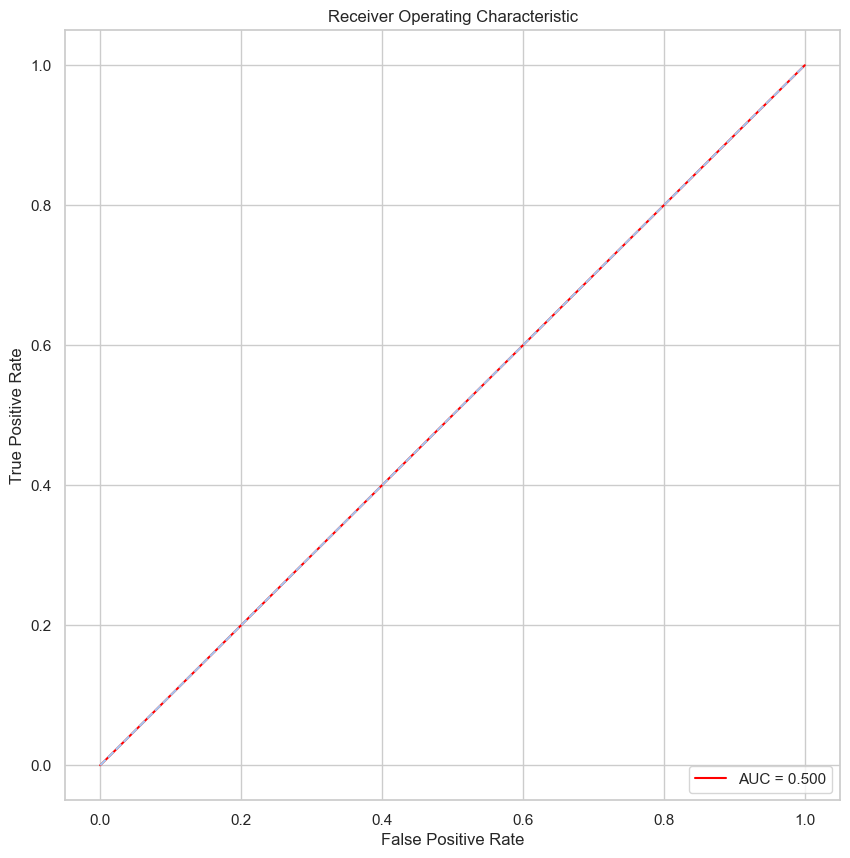

In [34]:
estimator = DummyClassifier(strategy='most_frequent')
evaluation(estimator)

### Modèles à tester

In [35]:
preprocessor = make_pipeline(SimpleImputer(missing_values = np.nan, strategy='median'),
                             SelectKBest(f_classif, k='all'))

In [36]:
RandomForest = make_pipeline(preprocessor,
                             RandomForestClassifier(class_weight='balanced',
                                                    random_state=39,
                                                    n_jobs=-1))

LogisticRegression = make_pipeline(preprocessor,
                                   StandardScaler(),
                                   LogisticRegression(class_weight='balanced',
                                                      random_state=39,
                                                      n_jobs=-1))

XGBoost = make_pipeline(preprocessor,
                        XGBClassifier(scale_pos_weight=(y_train.value_counts()[0]/y_train.value_counts()[1]),
                                      random_state=39,
                                      n_jobs=-1))

LightGBM = make_pipeline(preprocessor,
                         LGBMClassifier(class_weight='balanced',
                                        random_state=39,
                                        n_jobs=-1))

In [37]:
dict_of_models = {'RandomForest': RandomForest,
                  'LogisticRegression': LogisticRegression,
                  'XGBoost': XGBoost,
                  'LightGBM': LightGBM
                 }

----------------------------------------------------------------------

Modèle : RandomForest


C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [469 719 724 743] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


        pred_0  pred_1
test_0   84917       7
test_1    7318      11

Score métier = 73187 
(Le meilleur est le plus bas)

              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96     84924
         1.0       0.61      0.00      0.00      7329

    accuracy                           0.92     92253
   macro avg       0.77      0.50      0.48     92253
weighted avg       0.90      0.92      0.88     92253



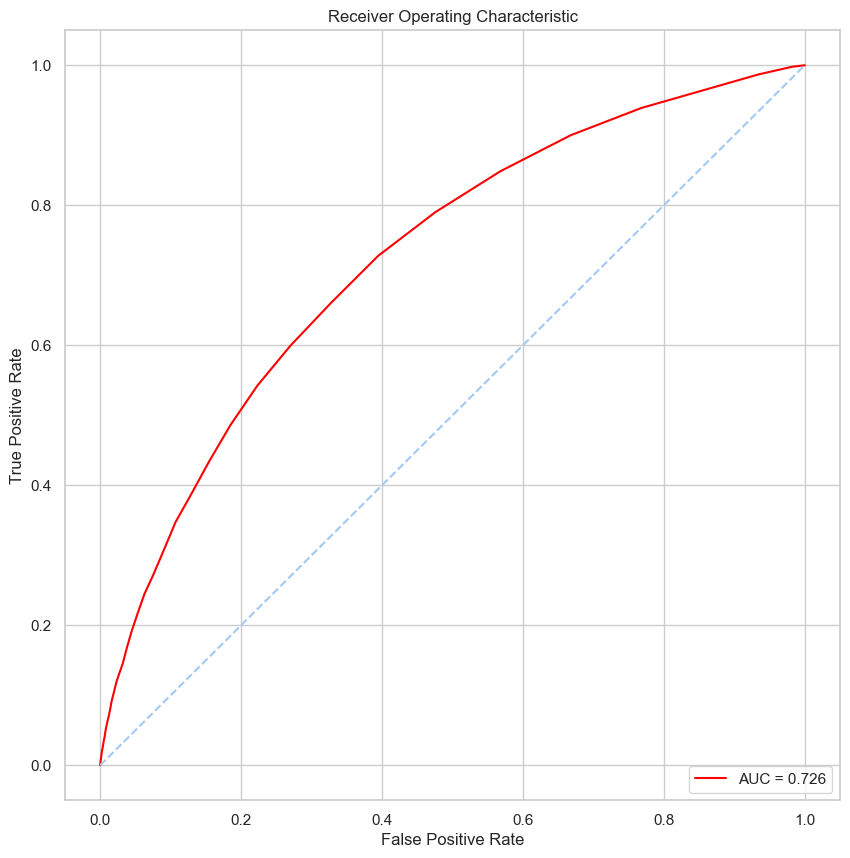

Modèle - fit, predict, scores - fait en 47s
----------------------------------------------------------------------

Modèle : LogisticRegression


C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [469 719 724 743] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


        pred_0  pred_1
test_0   60288   24636
test_1    2185    5144

Score métier = 46486 
(Le meilleur est le plus bas)

              precision    recall  f1-score   support

         0.0       0.97      0.71      0.82     84924
         1.0       0.17      0.70      0.28      7329

    accuracy                           0.71     92253
   macro avg       0.57      0.71      0.55     92253
weighted avg       0.90      0.71      0.78     92253



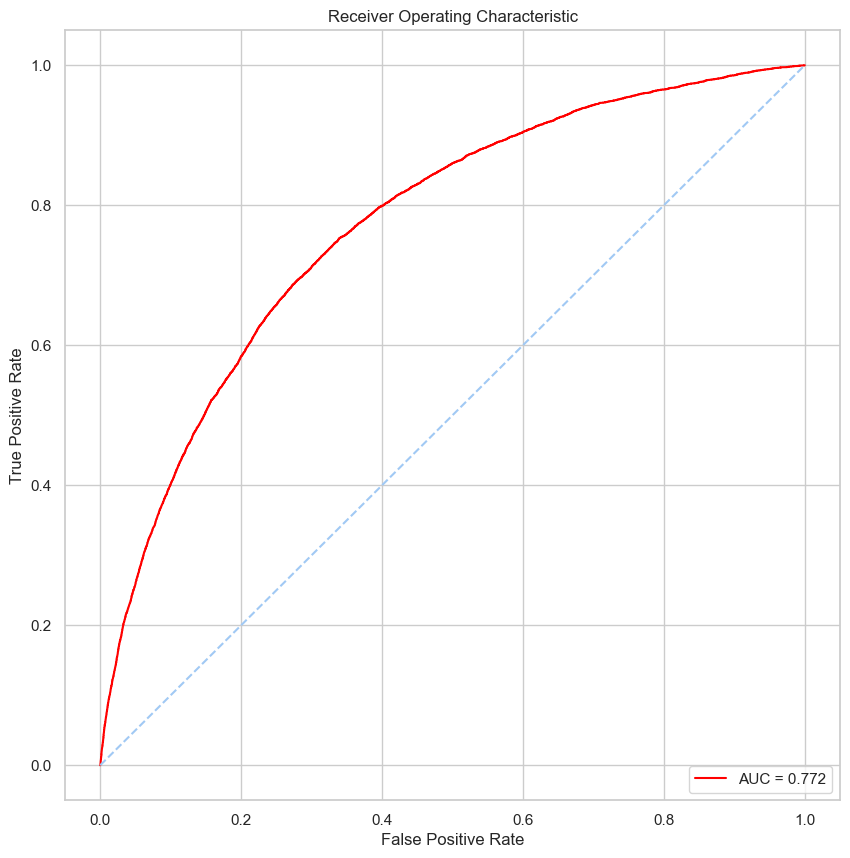

Modèle - fit, predict, scores - fait en 30s
----------------------------------------------------------------------

Modèle : XGBoost


C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [469 719 724 743] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


        pred_0  pred_1
test_0   66919   18005
test_1    2942    4387

Score métier = 47425 
(Le meilleur est le plus bas)

              precision    recall  f1-score   support

         0.0       0.96      0.79      0.86     84924
         1.0       0.20      0.60      0.30      7329

    accuracy                           0.77     92253
   macro avg       0.58      0.69      0.58     92253
weighted avg       0.90      0.77      0.82     92253



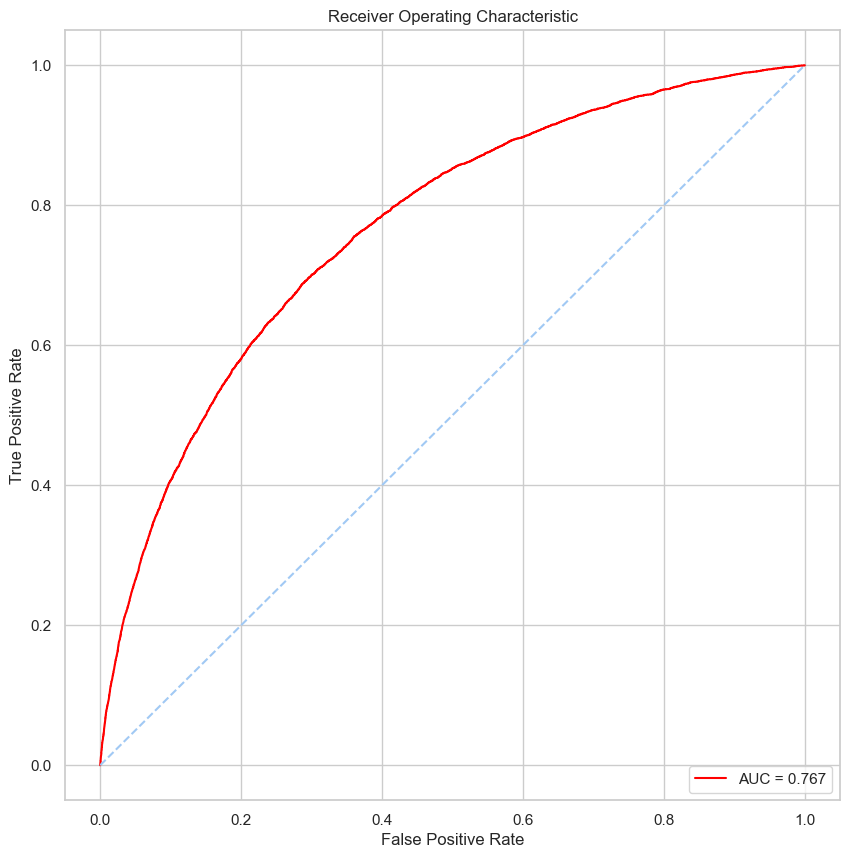

Modèle - fit, predict, scores - fait en 100s
----------------------------------------------------------------------

Modèle : LightGBM


C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [469 719 724 743] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


        pred_0  pred_1
test_0   62439   22485
test_1    2310    5019

Score métier = 45585 
(Le meilleur est le plus bas)

              precision    recall  f1-score   support

         0.0       0.96      0.74      0.83     84924
         1.0       0.18      0.68      0.29      7329

    accuracy                           0.73     92253
   macro avg       0.57      0.71      0.56     92253
weighted avg       0.90      0.73      0.79     92253



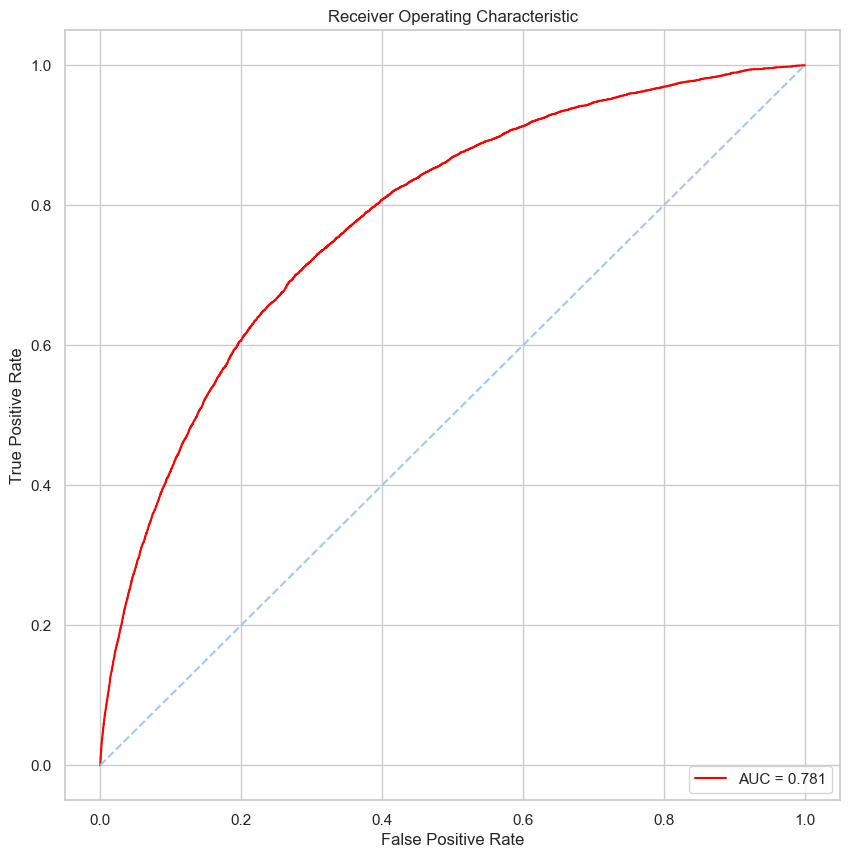

Modèle - fit, predict, scores - fait en 29s


In [32]:
for name, model in dict_of_models.items():
    with timer("Modèle - fit, predict, scores"):
        print('-'*70)
        print('\nModèle :', name)
        evaluation(model)

Actuellement, les **meilleurs résultats** sont apportés par **LightGBM**, en termes de scores métier et AUC et aussi en temps de calculs.

Mais, il est possible d'améliorer tous les modèles.
## Optimisation des modèles par validation croisée

In [52]:
hyper_params_modeles = {'RandomForest': {'randomforestclassifier__n_estimators': [10, 200],
                                         'randomforestclassifier__criterion': ['gini', 'entropy']},
                        'LogisticRegression': {'logisticregression__solver': ['newton-cholesky', 'sag']},
                        'XGBoost': {'xgbclassifier__max_depth': [2, 30],
                                    'xgbclassifier__subsample': [0.1, 1],
                                    'xgbclassifier__colsample_bytree': [0.1, 1]},
                        'LightGBM': {'lgbmclassifier__n_estimators': [10, 200],
                                     'lgbmclassifier__max_depth': [2, 30],
                                     'lgbmclassifier__colsample_bytree': [0.1, 1]}
                       }

In [43]:
def fonction_metier(y_true, y_pred):
    """Création d'un score métier : minimisation du coût d’erreur de prédiction des FN et FP (10 contre 1)"""
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sm = (10*fn+fp)
    return sm

Transformation de la fonction métier en score métier à utiliser comme scoring de la validation croisée :

In [44]:
score_metier = make_scorer(fonction_metier, greater_is_better=False)

In [36]:
def optimisation(model, name):
    grid = GridSearchCV(model, hyper_params_modeles[name], scoring=score_metier, cv=3, n_jobs=-1, return_train_score=True)
    grid.fit(X_train,y_train)
    y_pred_proba_train = grid.best_estimator_.predict_proba(X_train)[:,1]
    y_pred_proba_test = grid.best_estimator_.predict_proba(X_test)[:,1]
    
    print("\nRésultats de la validation croisée :")    
    for mean_train_train, std_train_train, params_train_train, mean_test_train, std_test_train, params_test_train in zip(
        grid.cv_results_['mean_train_score'], # score moyen sur train de validation
        grid.cv_results_['std_train_score'],  # écart-type du score sur train de validation
        grid.cv_results_['params'],           # valeur de l'hyperparamètre
        grid.cv_results_['mean_test_score'], # score moyen sur fold de test de validation
        grid.cv_results_['std_test_score'],  # écart-type du score sur fold de test de validation
        grid.cv_results_['params']           # valeur de l'hyperparamètre
        ):
        print("Score métier moyen sur les folds du jeu d'entraînement dans la CV = {:.2f} (+/-{:.02f}) pour {}".format(
            mean_train_train,
            std_train_train*2,
            params_train_train
        ))
        print("Score métier moyen sur les folds du jeu de test dans la CV = {:.2f} (+/-{:.02f}) pour {}".format(
            mean_test_train,
            std_test_train*2,
            params_test_train
        ))
    
    print('\nMeilleurs hyper-paramètres :',grid.best_params_)
    print("\nAUC sur le jeu d'entraînement complet")
    roc_auc(y_train, y_pred_proba_train)
    print("\nAUC sur le jeu de test")
    roc_auc(y_test, y_pred_proba_test)

------------------------------------------------------------------------------------------
RandomForest


C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [469 719 724 743] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



Résultats de la validation croisée :
Score métier moyen sur les folds du jeu d'entraînement dans la CV = -22541.33 (+/-1150.54) pour {'randomforestclassifier__criterion': 'gini', 'randomforestclassifier__n_estimators': 10}
Score métier moyen sur les folds du jeu de test dans la CV = -57957.67 (+/-119.51) pour {'randomforestclassifier__criterion': 'gini', 'randomforestclassifier__n_estimators': 10}
Score métier moyen sur les folds du jeu d'entraînement dans la CV = 0.00 (+/-0.00) pour {'randomforestclassifier__criterion': 'gini', 'randomforestclassifier__n_estimators': 200}
Score métier moyen sur les folds du jeu de test dans la CV = -58230.67 (+/-65.00) pour {'randomforestclassifier__criterion': 'gini', 'randomforestclassifier__n_estimators': 200}
Score métier moyen sur les folds du jeu d'entraînement dans la CV = -22390.67 (+/-1098.56) pour {'randomforestclassifier__criterion': 'entropy', 'randomforestclassifier__n_estimators': 10}
Score métier moyen sur les folds du jeu de test dans

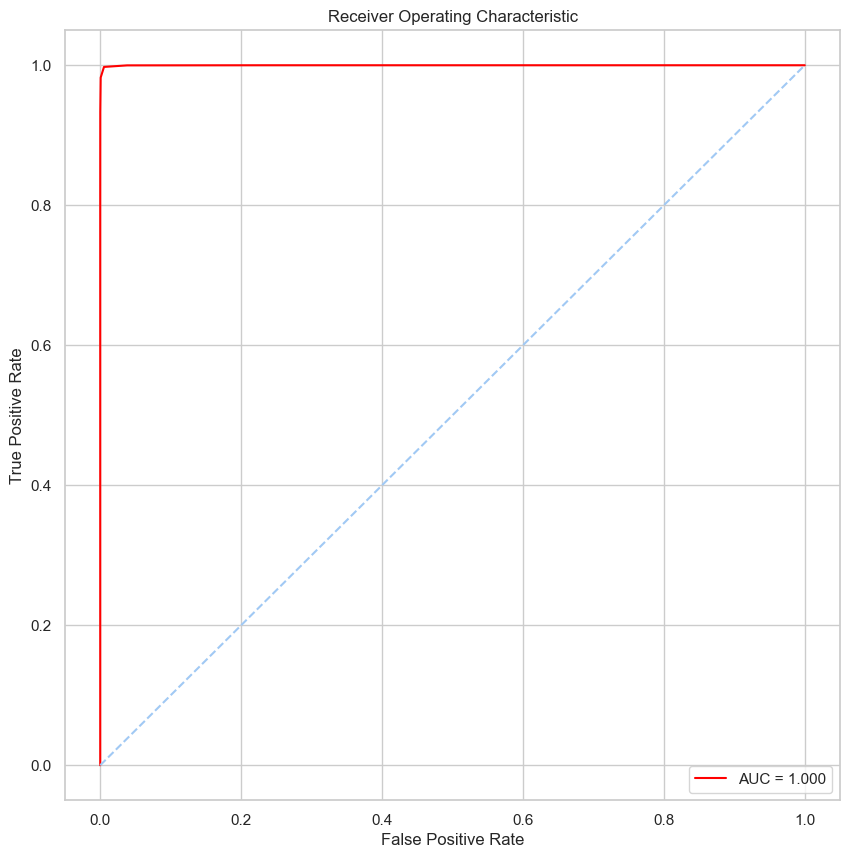


AUC sur le jeu de test


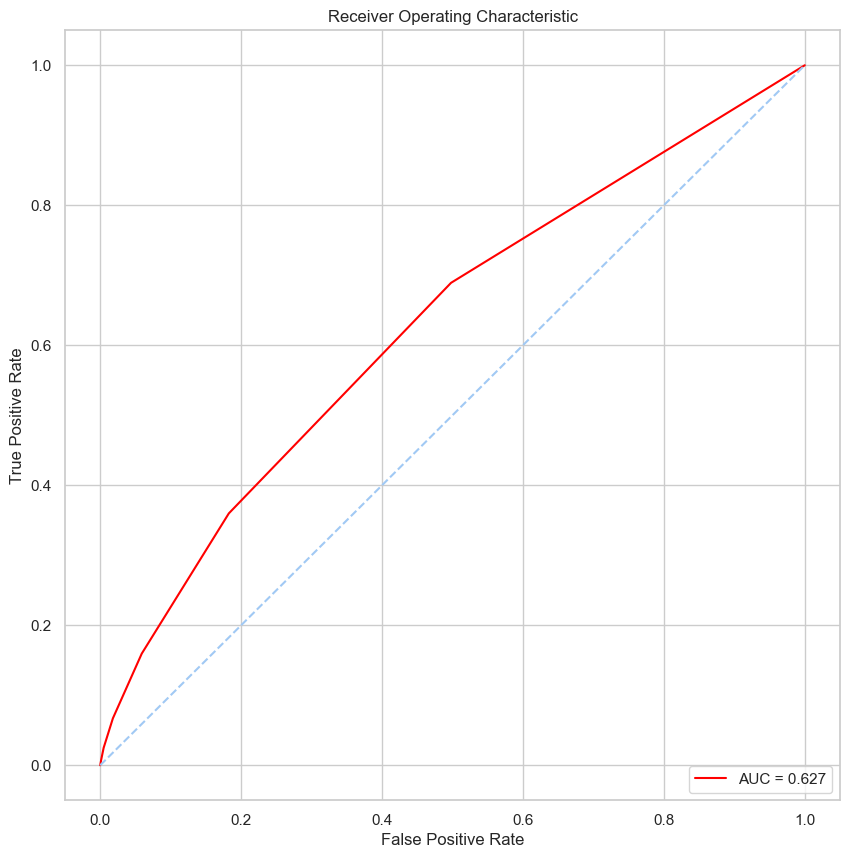

------------------------------------------------------------------------------------------
LogisticRegression


C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [469 719 724 743] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



Résultats de la validation croisée :
Score métier moyen sur les folds du jeu d'entraînement dans la CV = -70914.00 (+/-849.18) pour {'logisticregression__solver': 'newton-cholesky'}
Score métier moyen sur les folds du jeu de test dans la CV = -36993.33 (+/-825.05) pour {'logisticregression__solver': 'newton-cholesky'}
Score métier moyen sur les folds du jeu d'entraînement dans la CV = -71648.33 (+/-980.80) pour {'logisticregression__solver': 'sag'}
Score métier moyen sur les folds du jeu de test dans la CV = -37048.00 (+/-768.13) pour {'logisticregression__solver': 'sag'}

Meilleurs hyper-paramètres : {'logisticregression__solver': 'newton-cholesky'}

AUC sur le jeu d'entraînement complet


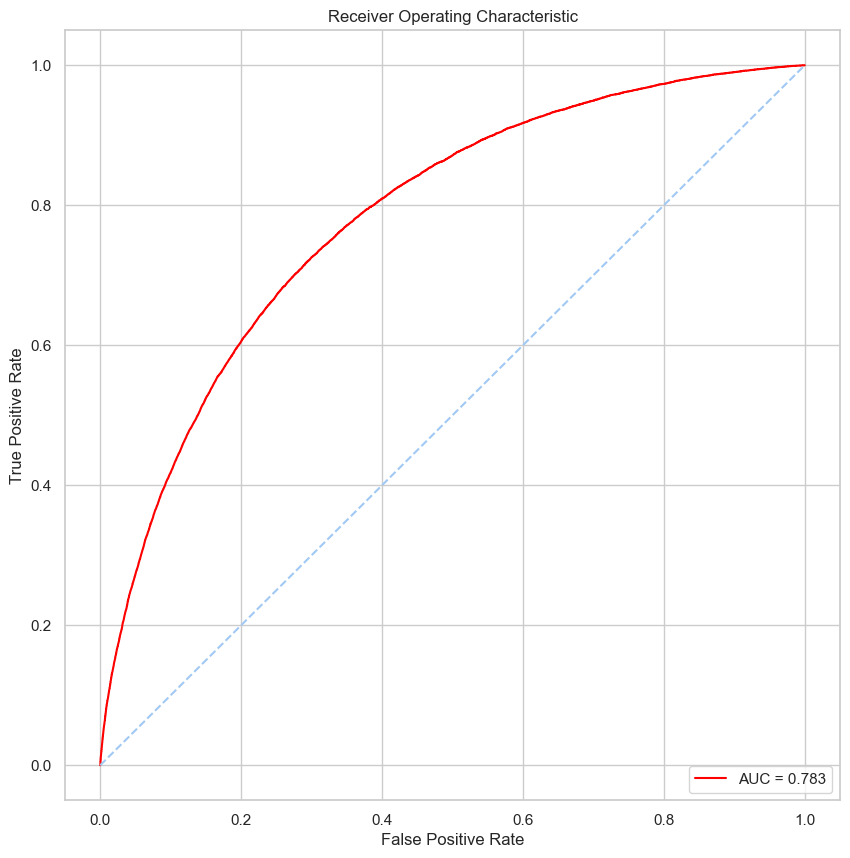


AUC sur le jeu de test


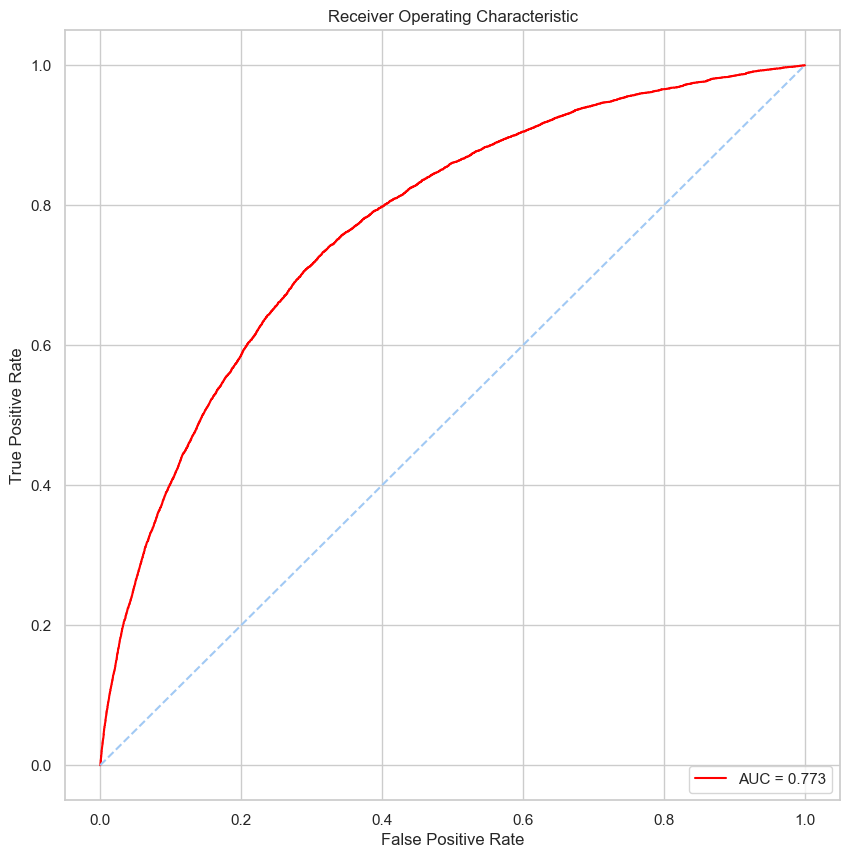

------------------------------------------------------------------------------------------
XGBoost


C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [469 719 724 743] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



Résultats de la validation croisée :
Score métier moyen sur les folds du jeu d'entraînement dans la CV = -74340.00 (+/-1159.07) pour {'xgbclassifier__colsample_bytree': 0.1, 'xgbclassifier__max_depth': 2, 'xgbclassifier__subsample': 0.1}
Score métier moyen sur les folds du jeu de test dans la CV = -38610.67 (+/-748.16) pour {'xgbclassifier__colsample_bytree': 0.1, 'xgbclassifier__max_depth': 2, 'xgbclassifier__subsample': 0.1}
Score métier moyen sur les folds du jeu d'entraînement dans la CV = -69583.33 (+/-1013.81) pour {'xgbclassifier__colsample_bytree': 0.1, 'xgbclassifier__max_depth': 2, 'xgbclassifier__subsample': 1}
Score métier moyen sur les folds du jeu de test dans la CV = -36458.33 (+/-584.09) pour {'xgbclassifier__colsample_bytree': 0.1, 'xgbclassifier__max_depth': 2, 'xgbclassifier__subsample': 1}
Score métier moyen sur les folds du jeu d'entraînement dans la CV = -80292.33 (+/-1535.39) pour {'xgbclassifier__colsample_bytree': 0.1, 'xgbclassifier__max_depth': 30, 'xgbclass

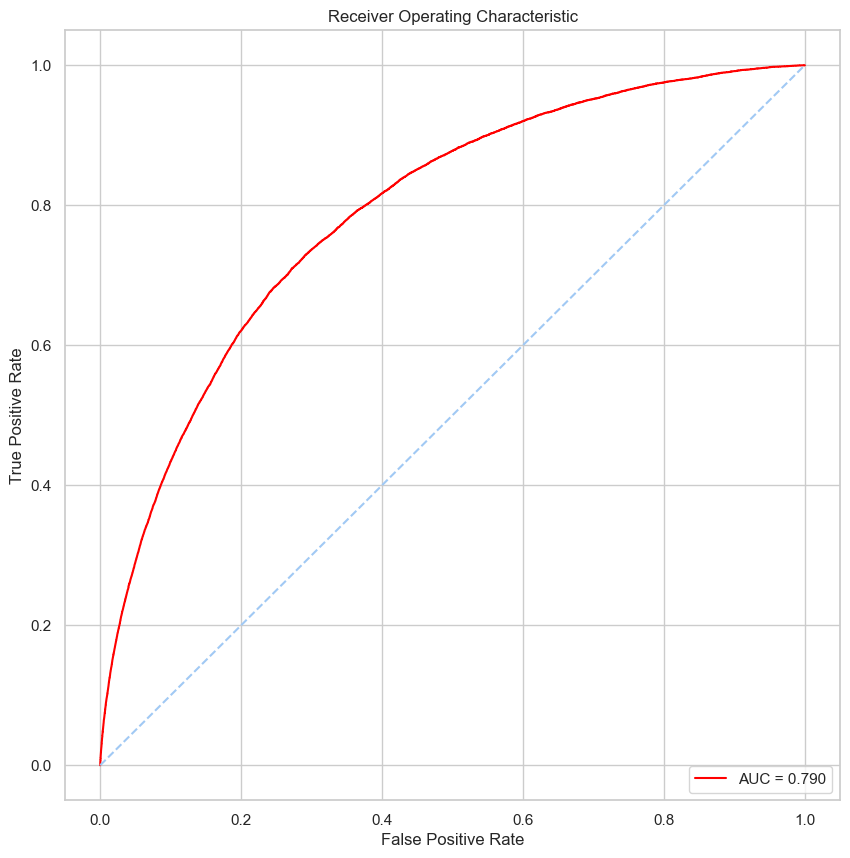


AUC sur le jeu de test


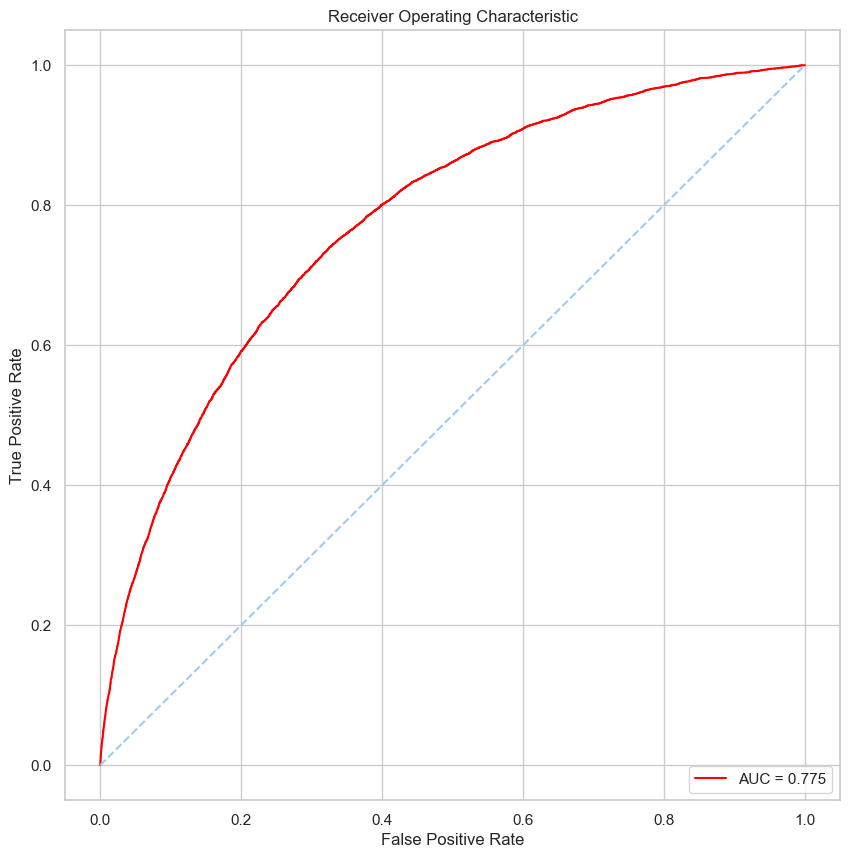

------------------------------------------------------------------------------------------
LightGBM


C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [469 719 724 743] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



Résultats de la validation croisée :
Score métier moyen sur les folds du jeu d'entraînement dans la CV = -90854.33 (+/-4431.16) pour {'lgbmclassifier__colsample_bytree': 0.1, 'lgbmclassifier__max_depth': 2, 'lgbmclassifier__n_estimators': 10, 'lgbmclassifier__num_leaves': 4, 'lgbmclassifier__subsample': 0.1}
Score métier moyen sur les folds du jeu de test dans la CV = -46256.00 (+/-1824.86) pour {'lgbmclassifier__colsample_bytree': 0.1, 'lgbmclassifier__max_depth': 2, 'lgbmclassifier__n_estimators': 10, 'lgbmclassifier__num_leaves': 4, 'lgbmclassifier__subsample': 0.1}
Score métier moyen sur les folds du jeu d'entraînement dans la CV = -90854.33 (+/-4431.16) pour {'lgbmclassifier__colsample_bytree': 0.1, 'lgbmclassifier__max_depth': 2, 'lgbmclassifier__n_estimators': 10, 'lgbmclassifier__num_leaves': 4, 'lgbmclassifier__subsample': 1}
Score métier moyen sur les folds du jeu de test dans la CV = -46256.00 (+/-1824.86) pour {'lgbmclassifier__colsample_bytree': 0.1, 'lgbmclassifier__max_

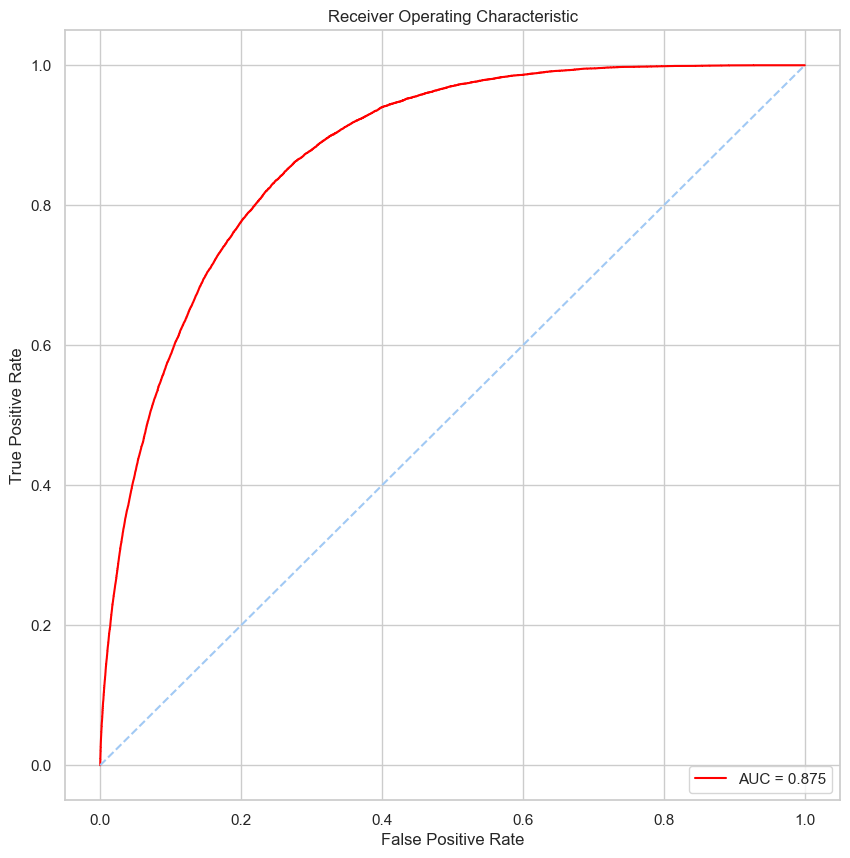


AUC sur le jeu de test


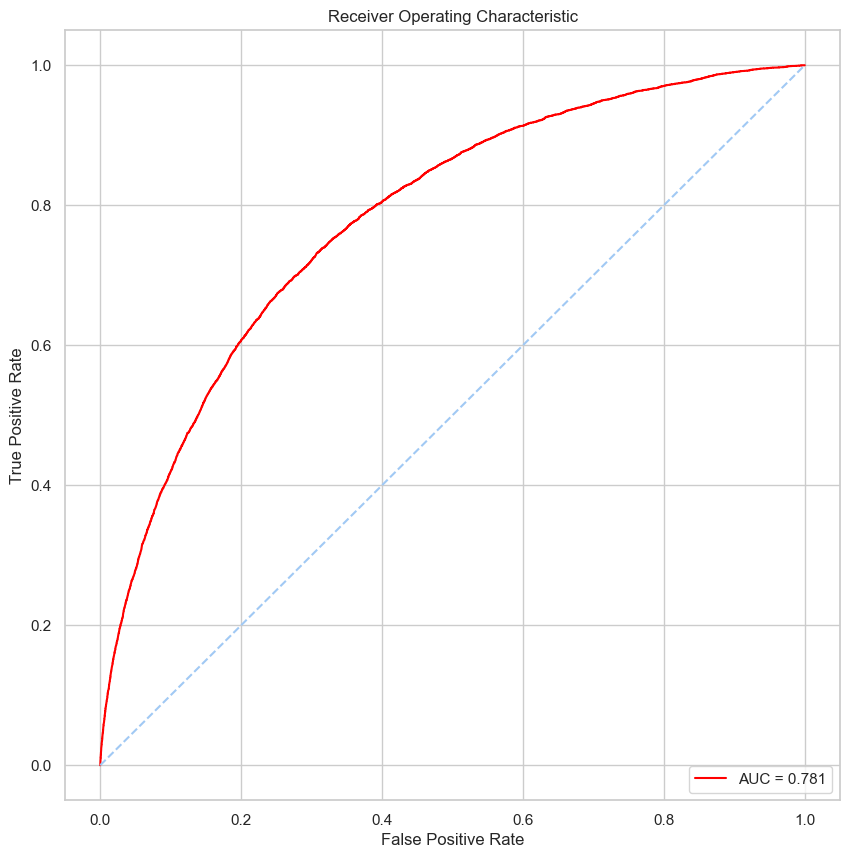

In [37]:
for nom, modele in dict_of_models.items():
    print('-'*90)
    print(nom)
    optimisation(modele, nom)

C'est finalement le modèle **LightGBM** qui obient les meilleurs scores, qu'il s'agisse de l'AUC sur le jeu de test et surtout du score métier.

C'est donc c'est algorithme que je vais tenter d'optimiser pour gagner encore plus de performance, à l'aide de **RandomizedSearchCV**.
## Optimisation poussée de l'algorithme LGBMClassifier
Je réalise un tracking des expériences avec **MLFlow** afin d'affiner le modèle au fil de l'eau sur plusieurs jours si besoin en m'appuyant sur les résultats passés avec une méthode en entonnoir.
### Hyper-paramètres et leur *range* à tester

In [65]:
hyper_params = {'pipeline__selectkbest__k': np.arange(1,2),# 762),
                'lgbmclassifier__n_estimators': [100],#, 300, 500, 700, 900, 1100, 1300, 1500, 1700, 1900],
                'lgbmclassifier__learning_rate': [0.001],# 0.01, 0.1, 1],
                'lgbmclassifier__num_leaves': np.arange(2,3),# 100),
                'lgbmclassifier__max_depth': np.arange(1,2),# 30)
                }

### Fonctions nécessaires au tracking par *MLFlow*

In [66]:
def yield_artifacts(run_id, path=None):
    """Yield all artifacts in the specified run"""
    client = MlflowClient()
    for item in client.list_artifacts(run_id, path):
        if item.is_dir:
            yield from yield_artifacts(run_id, item.path)
        else:
            yield item.path


def fetch_logged_data(run_id):
    """Fetch params, metrics, tags, and artifacts in the specified run"""
    client = MlflowClient()
    data = client.get_run(run_id).data
    # Exclude system tags: https://www.mlflow.org/docs/latest/tracking.html#system-tags
    tags = {k: v for k, v in data.tags.items() if not k.startswith("mlflow.")}
    artifacts = list(yield_artifacts(run_id, path_mlflow))
    return {
        "params": data.params,
        "metrics": data.metrics,
        "tags": tags,
        "artifacts": artifacts,
    }

In [73]:
def optimisation_finale(model, params):
    """Recherche des meilleurs hyper-paramètres sur le modèle choisi"""
    
    mlflow.sklearn.autolog()
    
    grid = RandomizedSearchCV(LightGBM, params, scoring=score_metier, cv=3,
                              n_iter=40, n_jobs=-1, return_train_score=True)
    
    grid.fit(X_train, y_train)
    
    run_id = mlflow.last_active_run()
    
    y_pred_proba_train = grid.best_estimator_.predict_proba(X_train)[:,1]
    y_pred_proba_test = grid.best_estimator_.predict_proba(X_test)[:,1]
    
    print("\nRésultats de la validation croisée :")    
    for mean_train_train, std_train_train, params_train_train, mean_test_train, std_test_train, params_test_train in zip(
        grid.cv_results_['mean_train_score'], # score moyen sur train de validation
        grid.cv_results_['std_train_score'],  # écart-type du score sur train de validation
        grid.cv_results_['params'],           # valeur de l'hyperparamètre
        grid.cv_results_['mean_test_score'], # score moyen sur fold de test de validation
        grid.cv_results_['std_test_score'],  # écart-type du score sur fold de test de validation
        grid.cv_results_['params']           # valeur de l'hyperparamètre
        ):
        print("Score métier moyen sur les folds du jeu d'entraînement dans la CV = {:.2f} (+/-{:.02f}) pour {}".format(
            mean_train_train,
            std_train_train*2,
            params_train_train
        ))
        print("Score métier moyen sur les folds du jeu de test dans la CV = {:.2f} (+/-{:.02f}) pour {}".format(
            mean_test_train,
            std_test_train*2,
            params_test_train
        ))
    
    print('\nMeilleurs hyper-paramètres :',grid.best_params_)
    print("\nAUC sur le jeu d'entraînement complet")
    roc_auc(y_train, y_pred_proba_train)
    print("\nAUC sur le jeu de test")
    roc_auc(y_test, y_pred_proba_test)
    return grid

2023/09/12 03:14:59 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\model_selection\_search.py:305: UserWarning: The total space of parameters 1 is smaller than n_iter=40. Running 1 iterations. For exhaustive searches, use GridSearchCV."
C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [468 718 723 742] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
2023/09/12 03:15:30 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: '\Users\Yann\Documents\Projet7-Implementez_un_modele_de_scoring\mlruns' does not exist.



Résultats de la validation croisée :
Score métier moyen sur les folds du jeu d'entraînement dans la CV = -95166.67 (+/-434.17) pour {'pipeline__selectkbest__k': 1, 'lgbmclassifier__num_leaves': 2, 'lgbmclassifier__n_estimators': 100, 'lgbmclassifier__max_depth': 1, 'lgbmclassifier__learning_rate': 0.001}
Score métier moyen sur les folds du jeu de test dans la CV = -47589.00 (+/-329.63) pour {'pipeline__selectkbest__k': 1, 'lgbmclassifier__num_leaves': 2, 'lgbmclassifier__n_estimators': 100, 'lgbmclassifier__max_depth': 1, 'lgbmclassifier__learning_rate': 0.001}

Meilleurs hyper-paramètres : {'pipeline__selectkbest__k': 1, 'lgbmclassifier__num_leaves': 2, 'lgbmclassifier__n_estimators': 100, 'lgbmclassifier__max_depth': 1, 'lgbmclassifier__learning_rate': 0.001}

AUC sur le jeu d'entraînement complet


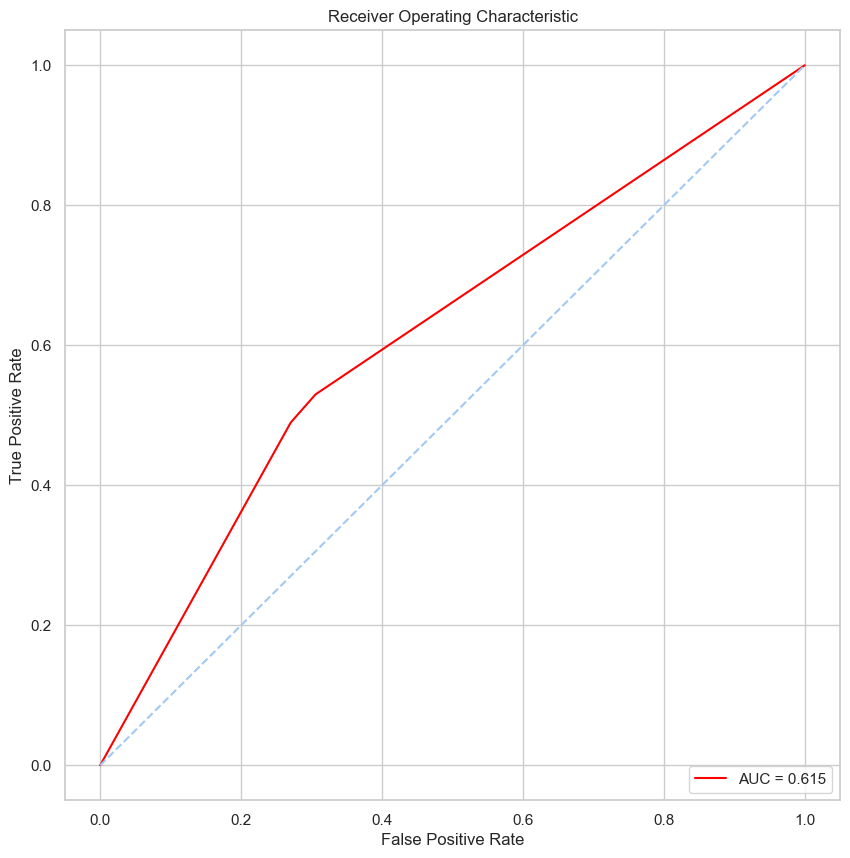


AUC sur le jeu de test


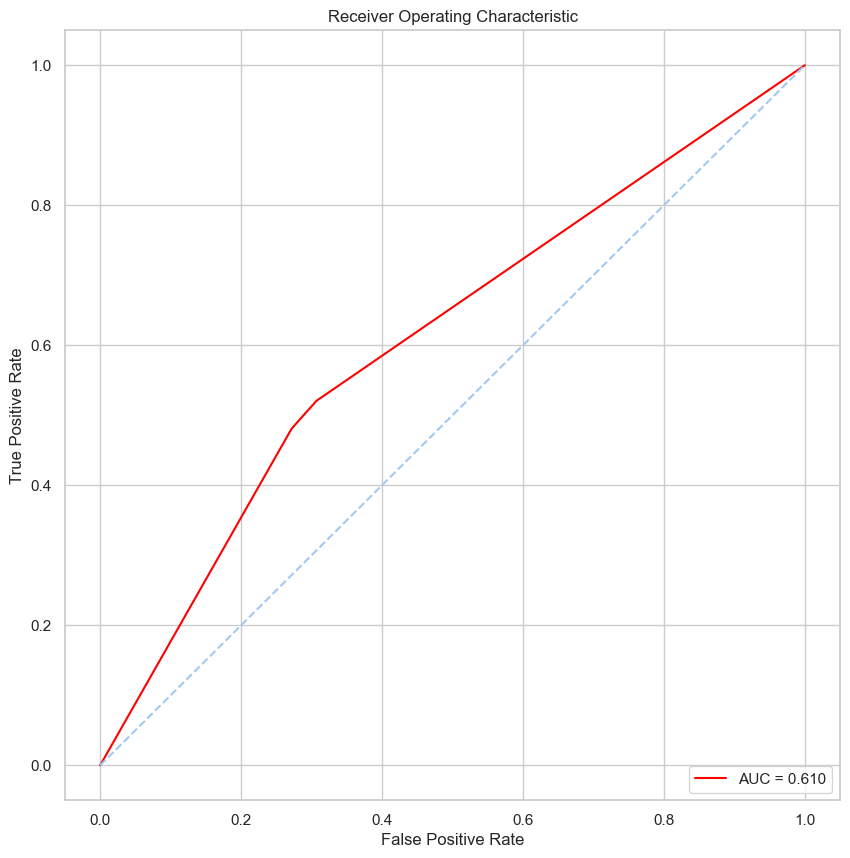

In [74]:
grid = optimisation_finale(LightGBM, hyper_params)

## Precision Recall Curve

In [ ]:
precision, recall, threshold = precision_recall_curve(y_test, grid.best_estimator_.decision_function(X_test))

In [ ]:
plt.plot(threshold, precision[:-1], label='precision')
plt.plot(threshold, precision[:-1], label='recall')
plt.legend()

In [ ]:
def model_final(model, X, threshold=0):
    return model.decision_function(X) > threshold

In [ ]:
y_pred = model_final(grid.best_estimator_, X_test, threshold=-1)

In [ ]:
pd.DataFrame(RandomForest.feature_importances_, index=X_train.columns).plot.bar(figsize=(12, 8))